In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
iris_dataset = pd.read_csv(r"C:\Users\pc\Desktop\Iris Flower Classification Project\iris.csv.csv")
iris_dataset.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
iris_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
print(iris_dataset.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [5]:
iris_dataset.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


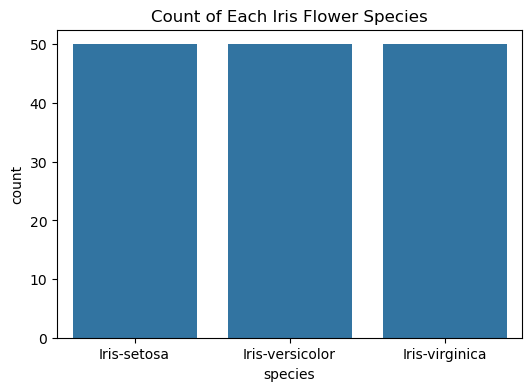

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='species', data=iris_dataset)
plt.title('Count of Each Iris Flower Species')
plt.show()

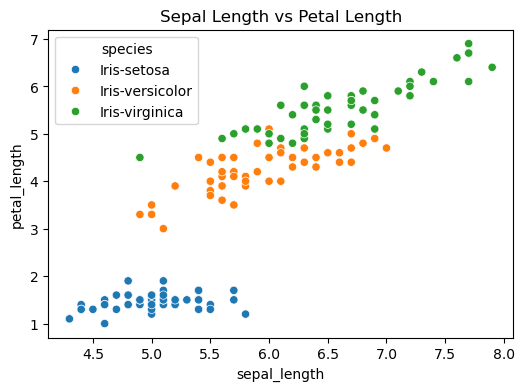

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='sepal_length',
    y='petal_length',
    hue='species',
    data=iris_dataset
)
plt.title('Sepal Length vs Petal Length')
plt.show()

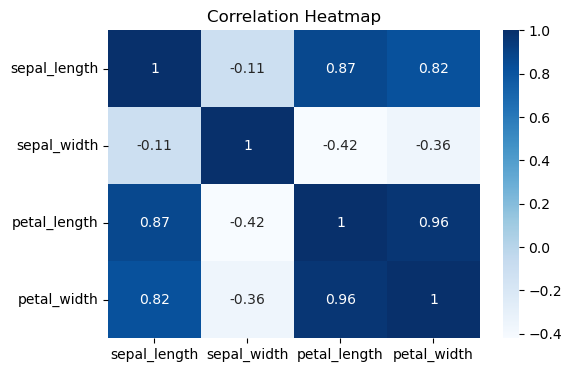

In [9]:
plt.figure(figsize=(6,4))
sns.heatmap(
    iris_dataset.drop('species', axis=1).corr(),
    annot=True,
    cmap='Blues'
)
plt.title('Correlation Heatmap')
plt.show()

In [10]:
X = iris_dataset[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = iris_dataset['species']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [13]:
predictions = model.predict(X_test)
print(predictions[:5])

['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor']


In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [15]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)

result = model.predict(new_flower)

print("Predicted Flower Species:", result[0])

Predicted Flower Species: Iris-setosa
